# Age Estimation from Facial Images — Notebook 01
## Data Loading, EDA, and Baseline Model

**Dataset:** UTKFace (Kaggle: `jangedoo/utkface-new`)

**Goal:** Establish a working pipeline end-to-end before iterating on architecture:
1. Load UTKFace and parse labels from filenames
2. Exploratory analysis (age distribution, gender/race balance — relevant for bias discussion later)
3. Train/val/test split
4. Baseline CNN (transfer learning, frozen backbone) trained as a regression model
5. Evaluate with MAE (standard metric for age estimation benchmarks)

This notebook is designed to run on Kaggle with GPU (T4) enabled.

## 1. Setup

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
from PIL import Image

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load data

On Kaggle: add the dataset `jangedoo/utkface-new` via 'Add Input'.
Path will be something like `/kaggle/input/utkface-new/UTKFace/`.

UTKFace filenames encode labels: `[age]_[gender]_[race]_[date&time].jpg`
- age: 0-116
- gender: 0 (male) or 1 (female)
- race: 0=White, 1=Black, 2=Asian, 3=Indian, 4=Others

In [4]:
# Adjust this path depending on environment (Kaggle vs local)
DATA_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

if not os.path.isdir(DATA_DIR):
    # fallback for local testing / alternate mount points
    candidates = glob.glob('/kaggle/input/**/UTKFace', recursive=True)
    if candidates:
        DATA_DIR = candidates[0]
    else:
        print('UTKFace directory not found yet — add the dataset as an input on Kaggle.')

print(f'Using DATA_DIR = {DATA_DIR}')

Using DATA_DIR = /kaggle/input/datasets/jangedoo/utkface-new/UTKFace


In [5]:
def parse_utkface_filename(path):
    """Parse age/gender/race from a UTKFace filename. Returns None if malformed."""
    fname = os.path.basename(path)
    m = re.match(r'^(\d+)_(\d+)_(\d+)_', fname)
    if not m:
        return None
    age, gender, race = map(int, m.groups())
    return {'path': path, 'age': age, 'gender': gender, 'race': race}

all_paths = glob.glob(os.path.join(DATA_DIR, '*.jpg'))
records = [parse_utkface_filename(p) for p in all_paths]
records = [r for r in records if r is not None]

df = pd.DataFrame(records)
print(f'Total valid images: {len(df)}')
print(f'Skipped malformed filenames: {len(all_paths) - len(df)}')
df.head()

Total valid images: 23705
Skipped malformed filenames: 3


,path,age,gender,race
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26,0,2
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22,1,1
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21,1,3
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28,0,0
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17,1,4


## 3. Exploratory Data Analysis

count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


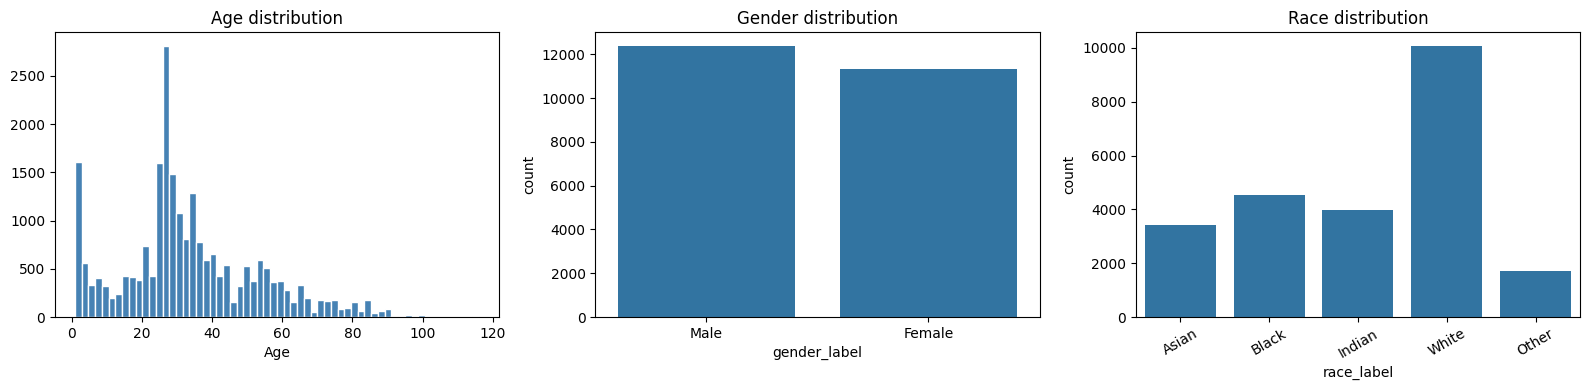

In [6]:
print(df['age'].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['age'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

gender_labels = {0: 'Male', 1: 'Female'}
df['gender_label'] = df['gender'].map(gender_labels)
sns.countplot(data=df, x='gender_label', ax=axes[1])
axes[1].set_title('Gender distribution')

race_labels = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Other'}
df['race_label'] = df['race'].map(race_labels)
sns.countplot(data=df, x='race_label', ax=axes[2])
axes[2].set_title('Race distribution')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120)
plt.show()

**Note for later (README / bias discussion):** UTKFace is known to be imbalanced —
skewed toward younger adults and toward the White category. Record the exact
numbers from the plot above; they'll go into the 'Limitations & Bias' section
of the project README, not skipped.

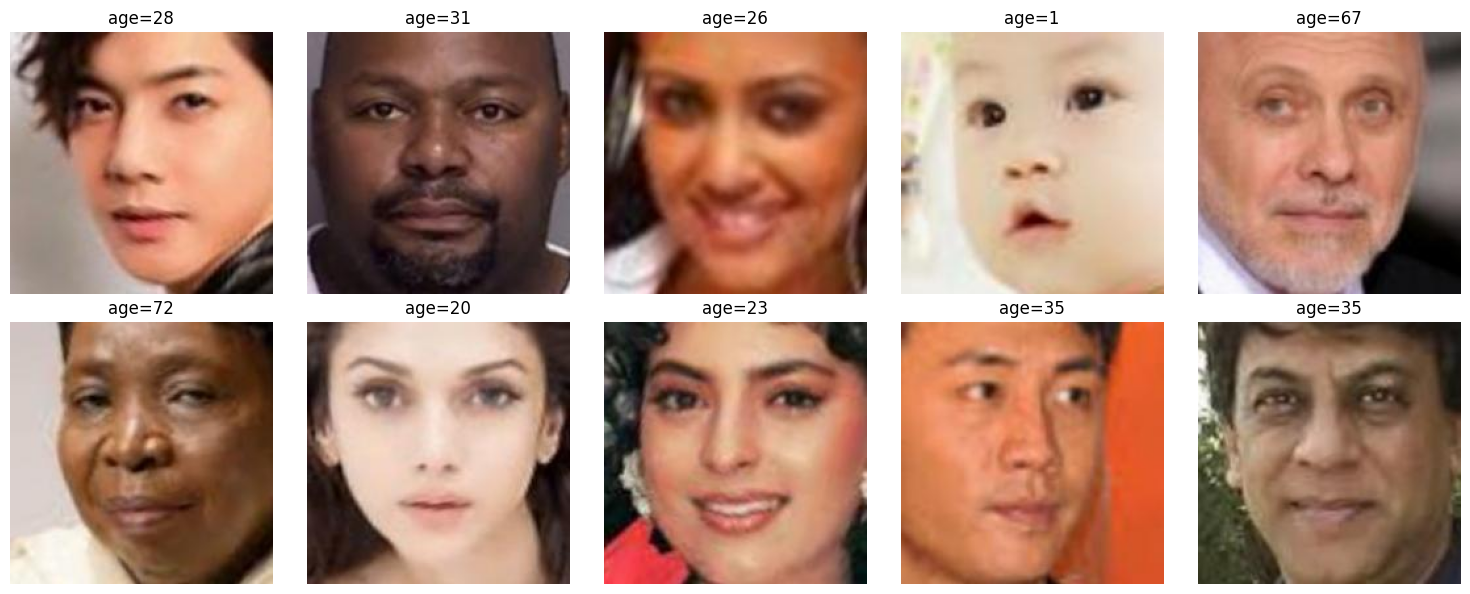

In [7]:
# Sample grid of images across the age range, to sanity-check labels visually
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_df = df.sample(10, random_state=SEED).reset_index(drop=True)
for i, ax in enumerate(axes.flat):
    img = Image.open(sample_df.loc[i, 'path'])
    ax.imshow(img)
    ax.set_title(f"age={sample_df.loc[i, 'age']}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_grid.png', dpi=120)
plt.show()

## 4. Train / Val / Test split

In [8]:
from sklearn.model_selection import train_test_split

# Stratify on a coarse age bucket so all splits have similar age distributions
df['age_bucket'] = pd.cut(df['age'], bins=[0,10,20,30,40,50,60,70,120], labels=False)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['age_bucket'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['age_bucket'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 18964 | Val: 2370 | Test: 2371


## 5. Dataset & DataLoader

In [9]:
IMG_SIZE = 128

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)
        age = torch.tensor(row['age'], dtype=torch.float32)
        return img, age

train_ds = UTKFaceDataset(train_df, train_transform)
val_ds = UTKFaceDataset(val_df, eval_transform)
test_ds = UTKFaceDataset(test_df, eval_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 297, val: 38, test: 38


## 6. Baseline model

ResNet18 pretrained on ImageNet, backbone frozen, replace the final FC layer with a
small regression head. This is intentionally simple — it's the baseline we'll beat
in later notebooks with fine-tuning, better augmentation, and a classification-vs-
regression comparison.

In [10]:
class AgeRegressionNet(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(1)

model = AgeRegressionNet(freeze_backbone=True).to(DEVICE)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


AgeRegressionNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

## 7. Training loop

In [11]:
criterion = nn.L1Loss()  # MAE directly as the loss — matches the eval metric
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_samples = 0.0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, ages in loader:
            imgs, ages = imgs.to(DEVICE), ages.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, ages)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)

    return total_loss / n_samples

In [12]:
EPOCHS = 15
PATIENCE = 4
best_val_mae = float('inf')
epochs_no_improve = 0
history = {'train_mae': [], 'val_mae': []}

for epoch in range(1, EPOCHS + 1):
    train_mae = run_epoch(train_loader, model, criterion, optimizer)
    val_mae = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_mae)

    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)
    print(f'Epoch {epoch:2d}/{EPOCHS} | train MAE: {train_mae:.2f} | val MAE: {val_mae:.2f}')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_baseline_model.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

print(f'\nBest val MAE: {best_val_mae:.2f} years')

Epoch  1/15 | train MAE: 13.95 | val MAE: 11.50
Epoch  2/15 | train MAE: 11.53 | val MAE: 10.97
Epoch  3/15 | train MAE: 11.13 | val MAE: 10.65
Epoch  4/15 | train MAE: 10.90 | val MAE: 10.38
Epoch  5/15 | train MAE: 10.61 | val MAE: 10.22
Epoch  6/15 | train MAE: 10.54 | val MAE: 10.08
Epoch  7/15 | train MAE: 10.40 | val MAE: 10.03
Epoch  8/15 | train MAE: 10.27 | val MAE: 9.97
Epoch  9/15 | train MAE: 10.26 | val MAE: 10.00
Epoch 10/15 | train MAE: 10.31 | val MAE: 9.90
Epoch 11/15 | train MAE: 10.21 | val MAE: 9.83
Epoch 12/15 | train MAE: 10.18 | val MAE: 9.82
Epoch 13/15 | train MAE: 10.11 | val MAE: 9.98
Epoch 14/15 | train MAE: 10.24 | val MAE: 10.08
Epoch 15/15 | train MAE: 10.09 | val MAE: 9.81

Best val MAE: 9.81 years


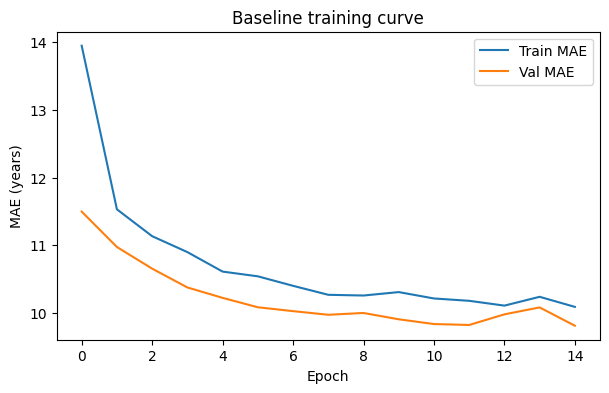

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_mae'], label='Train MAE')
plt.plot(history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (years)')
plt.title('Baseline training curve')
plt.legend()
plt.savefig('baseline_training_curve.png', dpi=120)
plt.show()

## 8. Test set evaluation

In [14]:
model.load_state_dict(torch.load('best_baseline_model.pt'))
test_mae = run_epoch(test_loader, model, criterion, optimizer=None)
print(f'Test MAE: {test_mae:.2f} years')

Test MAE: 9.68 years


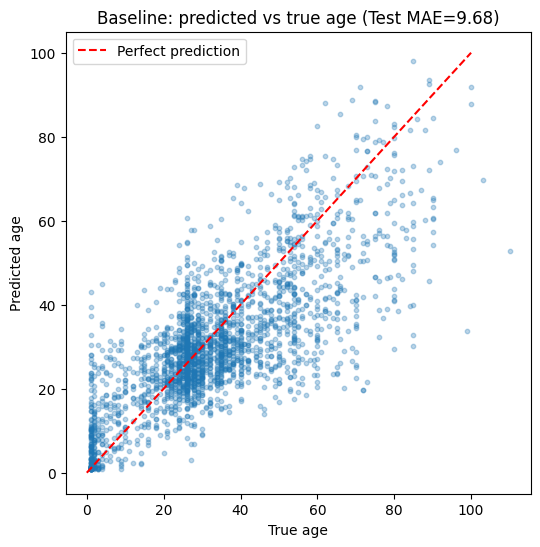

In [15]:
# Predictions vs ground truth scatter — quick visual check of systematic bias
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, ages in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(ages.numpy())

plt.figure(figsize=(6, 6))
plt.scatter(all_true, all_preds, alpha=0.3, s=10)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect prediction')
plt.xlabel('True age')
plt.ylabel('Predicted age')
plt.title(f'Baseline: predicted vs true age (Test MAE={test_mae:.2f})')
plt.legend()
plt.savefig('baseline_pred_vs_true.png', dpi=120)
plt.show()

## Summary & next steps

**Baseline result:** frozen ResNet18 + linear regression head, Test MAE recorded above.

**Next notebook (02):**
- Unfreeze and fine-tune the backbone (compare against this frozen baseline)
- Add face detection/alignment as a preprocessing step (MTCNN) and check if it improves MAE
- Try age-as-classification (binned) vs age-as-regression, compare
- Grad-CAM visualization for interpretability

**Artifacts saved by this notebook:** `best_baseline_model.pt`, EDA and result plots (PNG) —
keep these, they'll go straight into the README once we're happy with the numbers.